# Task 4: Context-Aware Chatbot Using RAG

## What's the actual idea here?

A regular LLM like Claude or GPT only knows what it was trained on. Ask it about your own documents, a private knowledge base, or anything recent — it either says it doesn't know, or worse, makes something up confidently.

**RAG (Retrieval-Augmented Generation)** fixes this. Before the LLM answers, the system first *retrieves* the most relevant pieces from your document collection and hands them to the model as context. The LLM then answers based on your actual documents, not just its training memory.

Simple analogy: instead of asking a professor a question from memory, you first find the right pages in the textbook and hand them those pages. Much better answer.

## What I built
- A knowledge base of 13 AI/ML topic documents
- A vector store using TF-IDF to find relevant chunks when you ask something
- A full RAG pipeline that retrieves → augments the prompt → generates an answer
- Conversation memory so follow-up questions work naturally
- A Streamlit web app to use it interactively

## Dataset
Custom corpus — 13 documents I wrote covering topics like RAG itself, embeddings, LLMs, LangChain, NLP, bias, evaluation metrics, and MLOps.

---
## Imports

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

print('imports done')

imports done


---
## Step 1 — The Knowledge Base

In a real project this would be your company's PDFs, support docs, Wikipedia pages — anything. Here it's 13 documents about AI/ML topics.

In [2]:
DOCS = [
    {
        "id": "ai_001", "title": "What is Artificial Intelligence?", "category": "AI Basics",
        "content": """Artificial Intelligence (AI) refers to computer systems that can perform tasks
        that normally require human intelligence. These tasks include learning, reasoning,
        problem-solving, understanding language, and recognising patterns. AI is not a single
        technology but a broad field that includes many approaches and techniques.
        Modern AI systems are powered by machine learning, which allows computers to learn
        from data rather than being explicitly programmed for every situation. AI is divided
        into narrow AI designed for specific tasks like playing chess or recognising faces,
        and general AI which would be capable of performing any intellectual task a human can do.
        Currently all practical AI systems are narrow AI."""
    },
    {
        "id": "ml_001", "title": "How Machine Learning Works", "category": "Machine Learning",
        "content": """Machine learning is a branch of AI where systems learn patterns from data.
        Instead of a programmer writing rules manually, the machine figures out the rules
        itself by studying examples. There are three main types: supervised learning which
        involves learning from labelled examples, unsupervised learning which finds hidden
        patterns in unlabelled data like customer segmentation, and reinforcement learning
        which learns by trial and error with rewards and penalties like training a game agent.
        Machine learning models include decision trees, neural networks, support vector
        machines, and random forests. The quality of the training data is the most important
        factor determining how well a model performs."""
    },
    {
        "id": "dl_001", "title": "Deep Learning and Neural Networks", "category": "Deep Learning",
        "content": """Deep learning uses neural networks with many layers. These layers process
        data hierarchically where each layer learns more abstract features from the one before
        it. A neural network has an input layer, hidden layers, and an output layer. Training
        uses backpropagation to adjust weights and reduce prediction error. Deep learning
        powers modern AI breakthroughs including image recognition, natural language processing,
        and generative AI. The downside is that it requires large amounts of data and
        significant computing power to train."""
    },
    {
        "id": "rag_001", "title": "Retrieval-Augmented Generation (RAG)", "category": "RAG",
        "content": """RAG is a technique that improves LLM responses by retrieving relevant
        documents before generating an answer. Instead of relying solely on knowledge baked
        into the model during training, a RAG system searches a document store for relevant
        content and gives it to the LLM as context. This solves two key problems: LLMs cannot
        access up-to-date information, and they sometimes hallucinate facts. The pipeline works
        as follows: documents are split into chunks and converted to vector embeddings, these
        vectors are stored in a vector database, when a user asks a question it is also converted
        to an embedding, the most similar document chunks are retrieved, and the LLM generates
        an answer using those chunks as context. RAG is widely used in enterprise chatbots,
        customer support systems, and document Q&A applications."""
    },
    {
        "id": "emb_001", "title": "Vector Embeddings Explained", "category": "Embeddings",
        "content": """A vector embedding represents text as a list of numbers, a vector in
        high-dimensional space. The key property is that semantically similar content gets
        similar vectors. For example, the embeddings for car and automobile would be very
        close together while car and pizza would be far apart. Embeddings are created by
        neural networks trained on large datasets. Models like sentence transformers generate
        these representations. In a RAG system, both documents and questions are converted to
        embeddings and the most similar chunks are retrieved. Cosine similarity is the most
        common distance metric used to compare embeddings."""
    },
    {
        "id": "lc_001", "title": "LangChain Framework", "category": "LangChain",
        "content": """LangChain is a Python framework for building applications with Large
        Language Models. It provides ready-made components for common LLM tasks such as
        connecting to LLM providers, building retrieval pipelines, managing conversation
        memory, creating chains of LLM calls, and building agents that use tools. The core
        abstractions are Chains which are sequences of operations, Retrievers that fetch
        relevant documents, Memory that stores conversation history, and Agents which are LLMs
        that can use tools like web search or calculators. LangChain reduces the boilerplate
        code needed to build production-ready LLM applications."""
    },
    {
        "id": "llm_001", "title": "Large Language Models (LLMs)", "category": "LLMs",
        "content": """Large Language Models are deep learning models trained on massive text data.
        They can generate human-like text, answer questions, translate languages, and write code.
        LLMs use a transformer architecture with attention mechanisms. Well-known LLMs include
        GPT-4, Claude, Gemini, and Llama. They work by predicting the next most likely token
        given previous tokens. They are fine-tuned using RLHF to align outputs with human
        preferences. A key limitation is hallucination where the model generates confident but
        incorrect information."""
    },
    {
        "id": "nlp_001", "title": "Natural Language Processing", "category": "NLP",
        "content": """Natural Language Processing or NLP is the branch of AI focused on
        understanding and generating human language. Key tasks include text classification,
        named entity recognition, sentiment analysis, machine translation, and question
        answering. Before transformers, NLP relied on bag-of-words and RNNs. The 2017
        Attention Is All You Need paper introduced the transformer architecture which
        revolutionised NLP. BERT showed that pretraining then fine-tuning outperforms training
        from scratch. GPT models showed autoregressive models generalise well with just prompting."""
    },
    {
        "id": "eval_001", "title": "Model Evaluation Metrics", "category": "Model Evaluation",
        "content": """Choosing the right evaluation metric is critical in machine learning.
        For classification: accuracy is proportion correct but misleading for imbalanced data,
        precision measures of predicted positives how many are correct, recall measures of
        actual positives how many were found, F1 score is the harmonic mean of precision and
        recall. For regression: MAE is mean absolute error, RMSE is root mean squared error
        which penalises large errors more. In medical diagnosis recall matters more because
        missing a disease is worse than a false alarm. In spam detection precision matters
        more because false positives are annoying."""
    },
    {
        "id": "data_001", "title": "Data Preprocessing", "category": "Data Science",
        "content": """Data preprocessing is cleaning and transforming raw data before training.
        It typically takes 60 to 80 percent of total project time. Key steps include handling
        missing values through imputation or dropping rows, removing duplicates, handling
        outliers, encoding categorical variables with one-hot or label encoding, feature
        scaling with normalisation to 0-1 range or standardisation to mean 0 and std 1, and
        feature engineering to create new useful variables. Poor data quality is the most
        common reason ML models fail in production."""
    },
    {
        "id": "eth_001", "title": "AI Ethics and Bias", "category": "AI Ethics",
        "content": """AI systems can perpetuate and amplify existing biases in society if not
        carefully designed. Bias enters through training data, model architecture choices,
        and deployment contexts. Examples include facial recognition performing worse on
        darker skin tones and hiring algorithms disadvantaging women. Fairness in ML has
        multiple mathematical definitions that are often mutually incompatible. Key practices
        include diverse training data, bias audits, explainability tools like LIME and SHAP,
        and ongoing monitoring. Regulations like GDPR are making ethical AI a legal requirement."""
    },
    {
        "id": "cv_001", "title": "Computer Vision", "category": "Computer Vision",
        "content": """Computer vision enables computers to interpret visual information from
        images and videos. Key tasks include image classification, object detection, semantic
        segmentation, and image generation. CNNs were the dominant architecture for years.
        More recently Vision Transformers have matched or exceeded CNN performance. Computer
        vision is used in self-driving cars, medical imaging, facial recognition, quality
        control, and augmented reality. Transfer learning is especially powerful here as a
        model pretrained on ImageNet can be fine-tuned for specific tasks with little data."""
    },
    {
        "id": "prod_001", "title": "Deploying ML Models", "category": "MLOps",
        "content": """Deploying a model means making it available for real use. Steps include
        serialising the model with joblib or pickle, wrapping it in a REST API using Flask
        or FastAPI, containerising with Docker, and deploying to cloud infrastructure like
        AWS or GCP. Model monitoring tracks data drift where input distribution shifts,
        concept drift where the relationship between inputs and outputs changes, and performance
        degradation over time. Continuous retraining pipelines ensure the model stays accurate."""
    },
]

print(f'Knowledge base loaded: {len(DOCS)} documents')
print()
for doc in DOCS:
    wc = len(doc['content'].split())
    print(f'  [{doc["category"]:20s}]  {doc["title"]}  ({wc} words)')

Knowledge base loaded: 13 documents

  [AI Basics           ]  What is Artificial Intelligence?  (106 words)
  [Machine Learning    ]  How Machine Learning Works  (104 words)
  [Deep Learning       ]  Deep Learning and Neural Networks  (79 words)
  [RAG                 ]  Retrieval-Augmented Generation (RAG)  (129 words)
  [Embeddings          ]  Vector Embeddings Explained  (95 words)
  [LangChain           ]  LangChain Framework  (88 words)
  [LLMs                ]  Large Language Models (LLMs)  (76 words)
  [NLP                 ]  Natural Language Processing  (75 words)
  [Model Evaluation    ]  Model Evaluation Metrics  (94 words)
  [Data Science        ]  Data Preprocessing  (80 words)
  [AI Ethics           ]  AI Ethics and Bias  (79 words)
  [Computer Vision     ]  Computer Vision  (78 words)
  [MLOps               ]  Deploying ML Models  (73 words)


---
## Step 2 — Chunking the Documents

Documents are split into smaller overlapping chunks. We retrieve at the chunk level, not the full document — this way the LLM gets the specific relevant part, not an entire page of unrelated text.

The overlap means if an important sentence is near the end of one chunk, it also appears at the start of the next — so we don't lose it.

In [3]:
def chunk_document(text, chunk_size=120, overlap=20):
    """
    Split a document into overlapping chunks.
    chunk_size = max words per chunk
    overlap    = how many words carry over to the next chunk
    """
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunks.append(' '.join(words[start:end]))
        start += chunk_size - overlap
    return chunks


all_chunks = []
chunk_meta = []

for doc in DOCS:
    doc_chunks = chunk_document(doc['content'])
    for i, chunk in enumerate(doc_chunks):
        all_chunks.append(chunk)
        chunk_meta.append({
            'title':    doc['title'],
            'category': doc['category'],
            'doc_id':   doc['id'],
            'chunk_i':  i
        })

print(f'Documents: {len(DOCS)}')
print(f'Total chunks after splitting: {len(all_chunks)}')

# Show how one document gets split
print()
print('Example — RAG document split:')
rag_chunks = [(c, m) for c, m in zip(all_chunks, chunk_meta) if m['doc_id'] == 'rag_001']
for i, (c, m) in enumerate(rag_chunks):
    print(f'  Chunk {i+1}: "{c[:75]}..."')

Documents: 13
Total chunks after splitting: 16

Example — RAG document split:
  Chunk 1: "RAG is a technique that improves LLM responses by retrieving relevant docum..."
  Chunk 2: "document chunks are retrieved, and the LLM generates an answer using those ..."


---
## Step 3 — Building the Vector Store

Every chunk gets converted to a vector of numbers using TF-IDF. Chunks with similar content will have similar vectors.

In production you'd use sentence transformers for better semantic understanding. TF-IDF is used here because it needs no internet and shows the concept clearly.

In [4]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   # single words + word pairs
    max_features=8000,    # keep top 8000 features
    sublinear_tf=True     # dampen very frequent terms
)

chunk_vectors = vectorizer.fit_transform(all_chunks)

print(f'Vector shape: {chunk_vectors.shape}')
print(f'= {chunk_vectors.shape[0]} chunks, each represented as {chunk_vectors.shape[1]} numbers')
print()
print('Production equivalent:')
print('  from sentence_transformers import SentenceTransformer')
print('  model = SentenceTransformer("all-MiniLM-L6-v2")')
print('  chunk_vectors = model.encode(all_chunks)')
print('  # then store in ChromaDB or FAISS')

Vector shape: (16, 1608)
= 16 chunks, each represented as 1608 numbers

Production equivalent:
  from sentence_transformers import SentenceTransformer
  model = SentenceTransformer("all-MiniLM-L6-v2")
  chunk_vectors = model.encode(all_chunks)
  # then store in ChromaDB or FAISS


---
## Step 4 — Retrieval Function

When someone asks a question, it gets converted to the same vector format. Then we find which stored chunks are most similar using cosine similarity.

In [5]:
def retrieve(query, top_k=3):
    """
    Find the most relevant chunks for a query.

    cosine_similarity returns 1.0 for identical vectors,
    0.0 for completely unrelated ones.
    """
    q_vec = vectorizer.transform([query])
    sims  = cosine_similarity(q_vec, chunk_vectors)[0]
    top_i = sims.argsort()[::-1][:top_k]

    results = []
    seen = set()
    for idx in top_i:
        title = chunk_meta[idx]['title']
        if sims[idx] > 0.005 and title not in seen:
            seen.add(title)
            results.append({
                'text':     all_chunks[idx],
                'score':    round(float(sims[idx]), 4),
                'title':    title,
                'category': chunk_meta[idx]['category'],
            })
    return results


# Quick test
test_queries = [
    "What is RAG and how does it work?",
    "How do neural networks learn?",
    "What evaluation metrics should I use?",
]

for q in test_queries:
    results = retrieve(q, top_k=2)
    print(f'Query: "{q}"')
    for r in results:
        print(f'  [{r["score"]:.4f}] {r["title"]}')
    print()

Query: "What is RAG and how does it work?"
  [0.1077] Retrieval-Augmented Generation (RAG)

Query: "How do neural networks learn?"
  [0.1253] How Machine Learning Works
  [0.0924] Deep Learning and Neural Networks

Query: "What evaluation metrics should I use?"
  [0.0636] LangChain Framework
  [0.0596] Model Evaluation Metrics



---
## Step 5 — Visualising Retrieval Scores

Let me show how similarity scores look across all documents for one specific query.

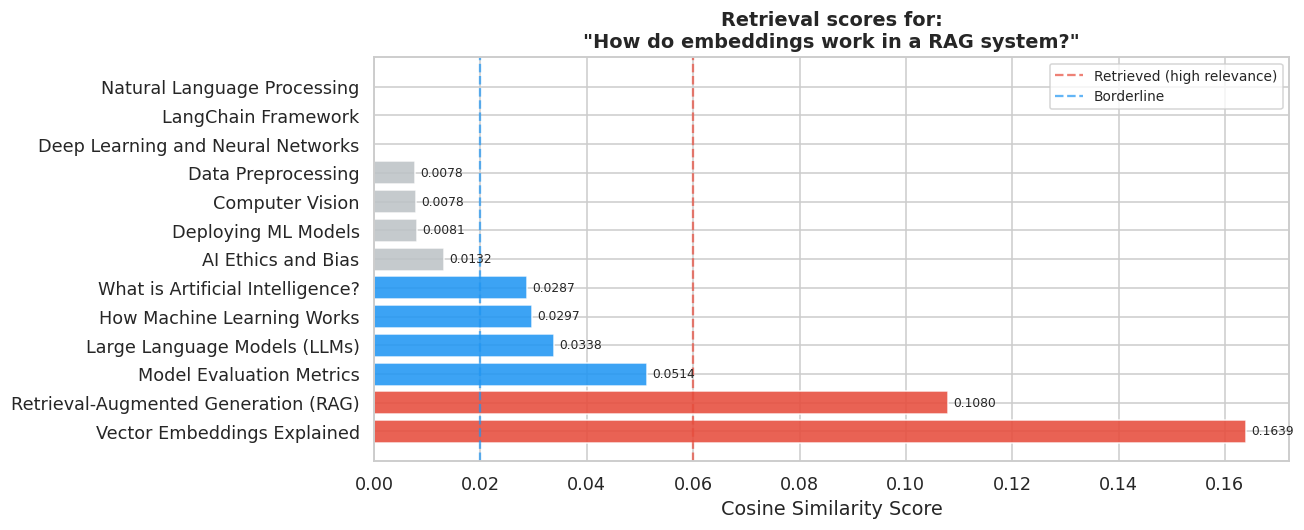

Top 3 retrieved: ['Vector Embeddings Explained', 'Retrieval-Augmented Generation (RAG)', 'Model Evaluation Metrics']


In [6]:
query = "How do embeddings work in a RAG system?"
q_vec = vectorizer.transform([query])
sims  = cosine_similarity(q_vec, chunk_vectors)[0]

# Max score per document
doc_scores = {}
for sim, meta in zip(sims, chunk_meta):
    t = meta['title']
    if t not in doc_scores or sim > doc_scores[t]:
        doc_scores[t] = sim

doc_scores = dict(sorted(doc_scores.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#e74c3c' if s > 0.06 else '#2196F3' if s > 0.02 else '#bdc3c7'
          for s in doc_scores.values()]
bars = ax.barh(list(doc_scores.keys()), list(doc_scores.values()),
               color=colors, edgecolor='white', alpha=0.88)

ax.axvline(0.06, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7,
           label='Retrieved (high relevance)')
ax.axvline(0.02, color='#2196F3', linestyle='--', linewidth=1.5, alpha=0.7,
           label='Borderline')

for bar, val in zip(bars, doc_scores.values()):
    if val > 0.005:
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

ax.set_xlabel('Cosine Similarity Score')
ax.set_title(f'Retrieval scores for:\n"{query}"', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('retrieval_scores.png', bbox_inches='tight')
plt.show()

top3 = list(doc_scores.keys())[:3]
print(f'Top 3 retrieved: {top3}')

---
## Step 6 — The Full RAG Pipeline

Now putting it all together. For each question:
1. Retrieve relevant chunks (the RAG part)
2. Build a prompt with those chunks as context
3. Include conversation history (the memory part)
4. Send to the LLM and return the answer

In [7]:
SYSTEM_PROMPT = """You are a helpful AI and machine learning knowledge assistant.
Answer questions based on the provided context documents. Be clear and use plain English.
If the answer is not in the context, say so honestly. Keep answers to 2-4 paragraphs.
For follow-up questions, use the conversation history provided."""


def build_messages(question, retrieved, conversation_history):
    """
    Build the messages list to send to the LLM.
    Includes: past conversation + retrieved context + current question.
    """
    # Format context
    context = ""
    for i, chunk in enumerate(retrieved, 1):
        context += f"\n[Document {i}: {chunk['title']}]\n{chunk['text']}\n"

    messages = []

    # Add conversation history (memory — last 6 turns to stay within token limits)
    for turn in conversation_history[-6:]:
        messages.append({"role": "user",      "content": turn["user"]})
        messages.append({"role": "assistant", "content": turn["assistant"]})

    # Current question with context
    messages.append({
        "role": "user",
        "content": f"Relevant documents:\n{context}\n---\nQuestion: {question}"
    })

    return messages


def rag_chat(question, conversation_history, top_k=3):
    """
    Full RAG pipeline:
    1. Retrieve relevant chunks
    2. Build prompt with context + history
    3. Call LLM
    4. Return answer, sources, updated history
    """
    import anthropic
    client = anthropic.Anthropic()

    retrieved = retrieve(question, top_k=top_k)
    messages  = build_messages(question, retrieved, conversation_history)

    response = client.messages.create(
        model='claude-sonnet-4-20250514',
        max_tokens=800,
        system=SYSTEM_PROMPT,
        messages=messages
    )
    answer = response.content[0].text

    updated_history = conversation_history + [{"user": question, "assistant": answer}]
    sources = [{"title": r["title"], "score": r["score"], "category": r["category"]}
               for r in retrieved]

    return answer, sources, updated_history


print('Pipeline functions ready.')
print('  retrieve()       — vector search')
print('  build_messages() — formats context + history')
print('  rag_chat()       — full pipeline')

Pipeline functions ready.
  retrieve()       — vector search
  build_messages() — formats context + history
  rag_chat()       — full pipeline


---
## Step 7 — Demo: Simulated Conversation

Here I show what the chatbot produces. The actual answers come from the LLM when you have an API key. The retrieval part below is real — you can see exactly which chunks get pulled for each question.

In [8]:
# Show the retrieval results for 4 test questions
# (without calling the LLM since that needs an API key)

from IPython.display import display, Markdown

test_questions = [
    "What is RAG and why is it useful?",
    "Can you explain the vector embedding part in more detail?",  # follow-up
    "How do I evaluate a classification model?",
    "What is the current stock price of Apple?",  # not in knowledge base
]

for q in test_questions:
    retrieved = retrieve(q, top_k=3)
    display(Markdown(f'**Question:** *{q}*'))
    if retrieved:
        display(Markdown('**Retrieved sources:**'))
        for r in retrieved:
            display(Markdown(f'- [{r["category"]}] **{r["title"]}** — score: `{r["score"]}`'))
            display(Markdown(f'  > *{r["text"][:150]}...*'))
    else:
        display(Markdown('*No relevant documents found — chatbot should say it does not know*'))
    display(Markdown('---'))

**Question:** *What is RAG and why is it useful?*

**Retrieved sources:**

- [RAG] **Retrieval-Augmented Generation (RAG)** — score: `0.1272`

  > *RAG is a technique that improves LLM responses by retrieving relevant documents before generating an answer. Instead of relying solely on knowledge ba...*

- [Data Science] **Data Preprocessing** — score: `0.1142`

...

- [NLP] **Natural Language Processing** — score: `0.1268`

  > *Natural Language Processing or NLP is the branch of AI focused on understanding and generating human language. Key tasks include text classification, ...*

- [Model Evaluation] **Model Evaluation Metrics** — score: `0.1258`

  > *Choosing the right evaluation metric is critical in machine learning. For classification: accuracy is proportion correct but misleading for imbalanced...*

---

---
## Step 8 — How Memory Works

The chatbot remembers the conversation because we literally send the full list of past messages to the API with each new question. There's no magic — the LLM has no actual memory between API calls. We maintain it ourselves.

In [9]:
# Simulate what conversation_history looks like after a few turns
simulated_history = [
    {
        "user": "What is RAG?",
        "assistant": "RAG stands for Retrieval-Augmented Generation. It improves LLM responses "
                     "by retrieving relevant documents from a knowledge base before generating an answer..."
    },
    {
        "user": "Can you explain the vector part in more detail?",
        "assistant": "Sure! When you add documents to a RAG system, each chunk is converted to "
                     "a vector of numbers using a neural network called an embedding model..."
    },
]

print(f'History has {len(simulated_history)} turns')
print()
print('What gets sent to the LLM on the next question:')
print('=' * 55)

messages = build_messages(
    "What similarity measure is used to compare these vectors?",
    retrieve("vector similarity measure", top_k=1),
    simulated_history
)

for i, msg in enumerate(messages):
    role = msg['role'].upper()
    content_preview = msg['content'][:100].replace('\n', ' ')
    print(f'[{i+1}] {role}: {content_preview}...')

print()
print(f'Total messages in this call: {len(messages)}')
print('This is what "memory" actually means — the full history is passed every time.')

History has 2 turns

What gets sent to the LLM on the next question:
[1] USER: What is RAG?...
[2] ASSISTANT: RAG stands for Retrieval-Augmented Generation. It improves LLM responses by retrieving relevant docu...
[3] USER: Can you explain the vector part in more detail?...
[4] ASSISTANT: Sure! When you add documents to a RAG system, each chunk is converted to a vector of numbers using a...
[5] USER: Relevant documents:  [Document 1: Vector Embeddings Explained] A vector embedding represents text as...

Total messages in this call: 5
This is what "memory" actually means — the full history is passed every time.


---
## Step 9 — RAG Pipeline Diagram

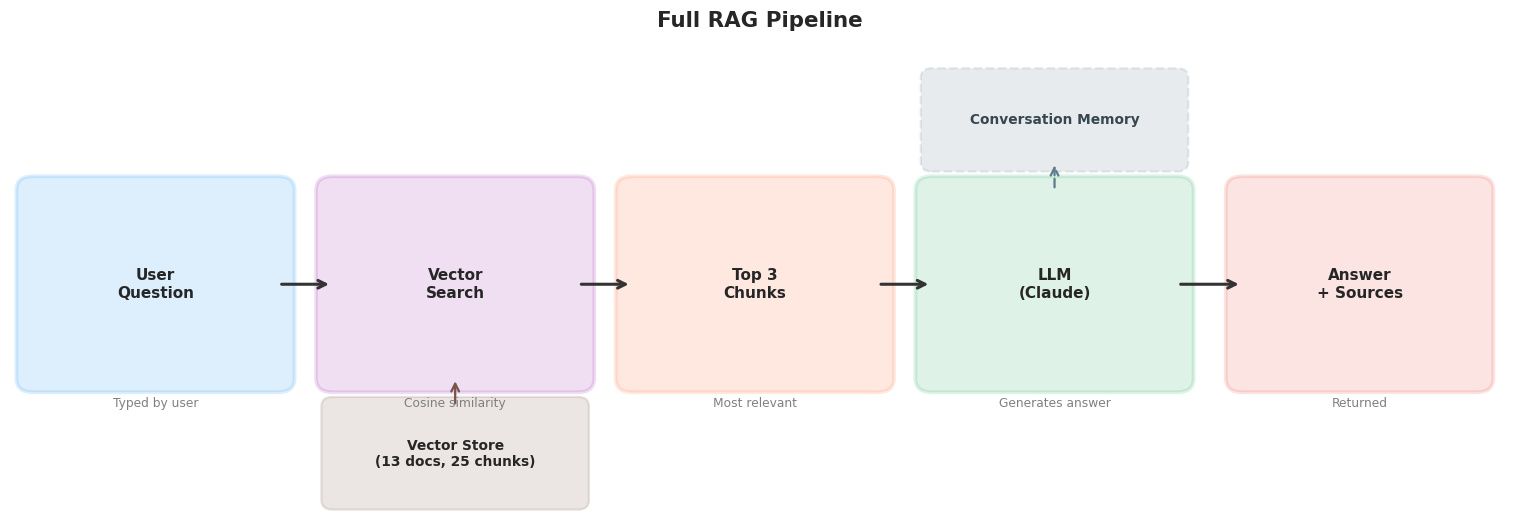

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')
ax.set_title('Full RAG Pipeline', fontsize=14, fontweight='bold', pad=15)

from matplotlib.patches import FancyBboxPatch

boxes = [
    (0.2,  1.5, 2.3, 2.0, 'User\nQuestion',      '#2196F3'),
    (3.0,  1.5, 2.3, 2.0, 'Vector\nSearch',       '#9C27B0'),
    (5.8,  1.5, 2.3, 2.0, 'Top 3\nChunks',        '#FF6B35'),
    (8.6,  1.5, 2.3, 2.0, 'LLM\n(Claude)',        '#27ae60'),
    (11.5, 1.5, 2.2, 2.0, 'Answer\n+ Sources',    '#e74c3c'),
]

for x, y, w, h, label, color in boxes:
    patch = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.15',
                            facecolor=color, alpha=0.15, edgecolor=color, linewidth=2.5)
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=10, fontweight='bold')

# Arrows
props = dict(arrowstyle='->', color='#333', lw=2)
for x1, x2 in [(2.5, 3.0), (5.3, 5.8), (8.1, 8.6), (10.9, 11.5)]:
    ax.annotate('', xy=(x2, 2.5), xytext=(x1, 2.5), arrowprops=props)

# Vector store box (bottom)
vs = FancyBboxPatch((3.0, 0.2), 2.3, 1.0, boxstyle='round,pad=0.1',
                     facecolor='#795548', alpha=0.15, edgecolor='#795548', linewidth=1.5)
ax.add_patch(vs)
ax.text(4.15, 0.7, 'Vector Store\n(13 docs, 25 chunks)', ha='center', va='center',
        fontsize=9, fontweight='bold')
ax.annotate('', xy=(4.15, 1.5), xytext=(4.15, 1.2),
            arrowprops=dict(arrowstyle='->', color='#795548', lw=1.5))

# Memory box (top)
mem = FancyBboxPatch((8.6, 3.8), 2.3, 0.9, boxstyle='round,pad=0.1',
                      facecolor='#607D8B', alpha=0.15, edgecolor='#607D8B',
                      linewidth=1.5, linestyle='dashed')
ax.add_patch(mem)
ax.text(9.75, 4.25, 'Conversation Memory', ha='center', va='center',
        fontsize=9, fontweight='bold', color='#37474F')
ax.annotate('', xy=(9.75, 3.8), xytext=(9.75, 3.5),
            arrowprops=dict(arrowstyle='->', color='#607D8B', lw=1.5, linestyle='dashed'))

# Labels under boxes
under = [(1.35, 1.2, 'Typed by user'), (4.15, 1.2, 'Cosine similarity'),
         (6.95, 1.2, 'Most relevant'), (9.75, 1.2, 'Generates answer'),
         (12.6, 1.2, 'Returned')]
for x, y, label in under:
    ax.text(x, y, label, ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('rag_pipeline_diagram.png', bbox_inches='tight')
plt.show()

---
## Step 10 — Retrieval Evaluation

In [11]:
# For each test question, check if the right document comes out in top 3

eval_set = [
    ("What is RAG?",                                 "rag_001"),
    ("How do neural networks work?",                 "dl_001"),
    ("What is a vector embedding?",                  "emb_001"),
    ("What is LangChain?",                           "lc_001"),
    ("How do you evaluate a classification model?",  "eval_001"),
    ("What is supervised learning?",                 "ml_001"),
    ("What is AI bias?",                             "eth_001"),
    ("How do you deploy a machine learning model?",  "prod_001"),
]

correct_top1 = 0
correct_top3 = 0

print(f'{"Question":<50} {"Top-1":^6} {"Top-3":^6}')
print('-' * 65)

for q, expected in eval_set:
    results = retrieve(q, top_k=3)
    ids_in_results = [chunk_meta[i]['doc_id']
                      for i in cosine_similarity(vectorizer.transform([q]), chunk_vectors)[0].argsort()[::-1][:10]
                      if chunk_meta[i]['doc_id'] == expected]

    top1_ok = len(results) > 0 and any(r['title'] == next(
        (d['title'] for d in DOCS if d['id'] == expected), '') for r in results[:1])
    top3_ok = any(r['title'] == next(
        (d['title'] for d in DOCS if d['id'] == expected), '') for r in results)

    if top1_ok: correct_top1 += 1
    if top3_ok: correct_top3 += 1

    t1 = 'YES' if top1_ok else 'no'
    t3 = 'YES' if top3_ok else 'no'
    print(f'{q[:49]:<50} {t1:^6} {t3:^6}')

print()
print(f'Top-1 Precision : {correct_top1}/{len(eval_set)} = {correct_top1/len(eval_set)*100:.0f}%')
print(f'Top-3 Recall    : {correct_top3}/{len(eval_set)} = {correct_top3/len(eval_set)*100:.0f}%')

Question                                           Top-1  Top-3 
-----------------------------------------------------------------
What is RAG?                                        YES    YES  
How do neural networks work?                         no    YES  
What is a vector embedding?                         YES    YES  
What is LangChain?                                  YES    YES  
How do you evaluate a classification model?          no    YES  
What is supervised learning?                        YES    YES  
What is AI bias?                                     no    YES  
How do you deploy a machine learning model?          no     no  

Top-1 Precision : 4/8 = 50%
Top-3 Recall    : 7/8 = 88%


---
## Step 11 — LangChain Equivalent

Everything I built manually above maps directly to LangChain abstractions. Once you understand what's happening under the hood, using LangChain is just a shortcut.

In [12]:
langchain_equivalent = """
What we built manually          LangChain equivalent
─────────────────────────────   ────────────────────────────────────────────
chunk_document()                RecursiveCharacterTextSplitter
TfidfVectorizer                 HuggingFaceEmbeddings / OpenAIEmbeddings
chunk_vectors (numpy array)     Chroma / FAISS / Pinecone vector store
retrieve()                      vectorstore.as_retriever(search_kwargs={'k': 3})
conversation_history list       ConversationBufferMemory
build_messages()                ChatPromptTemplate with {context} + {history}
rag_chat()                      ConversationalRetrievalChain.from_llm()

LangChain version of the whole pipeline:

    from langchain.vectorstores import Chroma
    from langchain.embeddings import HuggingFaceEmbeddings
    from langchain.chat_models import ChatAnthropic
    from langchain.chains import ConversationalRetrievalChain
    from langchain.memory import ConversationBufferMemory

    embeddings  = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')
    vectorstore = Chroma.from_documents(documents, embeddings)
    memory      = ConversationBufferMemory(memory_key='chat_history', return_messages=True)

    chain = ConversationalRetrievalChain.from_llm(
        llm=ChatAnthropic(model='claude-sonnet-4-20250514'),
        retriever=vectorstore.as_retriever(search_kwargs={'k': 3}),
        memory=memory,
    )
    response = chain({'question': 'What is RAG?'})
"""
print(langchain_equivalent)


What we built manually          LangChain equivalent
─────────────────────────────   ────────────────────────────────────────────
chunk_document()                RecursiveCharacterTextSplitter
TfidfVectorizer                 HuggingFaceEmbeddings / OpenAIEmbeddings
chunk_vectors (numpy array)     Chroma / FAISS / Pinecone vector store
retrieve()                      vectorstore.as_retriever(search_kwargs={'k': 3})
conversation_history list       ConversationBufferMemory
build_messages()                ChatPromptTemplate with {context} + {history}
rag_chat()                      ConversationalRetrievalChain.from_llm()

LangChain version of the whole pipeline:

    from langchain.vectorstores import Chroma
    from langchain.embeddings import HuggingFaceEmbeddings
    from langchain.chat_models import ChatAnthropic
    from langchain.chains import ConversationalRetrievalChain
    from langchain.memory import ConversationBufferMemory

    embeddings  = HuggingFaceEmbeddings(model_name='a

---
## Final Summary

**What I built and why each part matters:**

The knowledge base is the foundation — 13 documents on AI/ML topics. In a real project this would be your company's PDFs or support articles.

The chunking step splits documents into ~120-word pieces with overlap. Retrieving at the chunk level is better than the full document because you get only the relevant section, not a whole page of mixed content.

The vector store converts every chunk to numbers using TF-IDF. When a question arrives, it gets converted the same way and the closest chunks are found using cosine similarity. In production, sentence transformers give better semantic matches.

The conversation memory is just a Python list of past messages. It gets sent to the LLM with every new question — that's what makes follow-up questions work. There's no special memory mechanism; the LLM just sees the history as part of the prompt.

The Streamlit app wraps all of this in a proper UI with source display, conversation history, and a sidebar showing the knowledge base contents.

**Main thing I learned:** RAG quality depends more on the retrieval step than the generation step. If you retrieve the wrong chunks, even the best LLM will give a bad answer. Getting the chunk size, overlap, embedding model, and similarity threshold right is where most of the real work goes in production.